# Temporal Convolutional Networks From Scratch

## 1. Why Temporal Convolutional Networks Come Next

The previous notebook showed that a 1D CNN can learn local temporal patterns.

A standard convolution, however, does not automatically guarantee that:

- future values are excluded,
- long-range temporal dependencies are covered efficiently.

A **Temporal Convolutional Network (TCN)** addresses these issues using:

```text
causal convolution
+
dilated convolution
+
residual connections
```

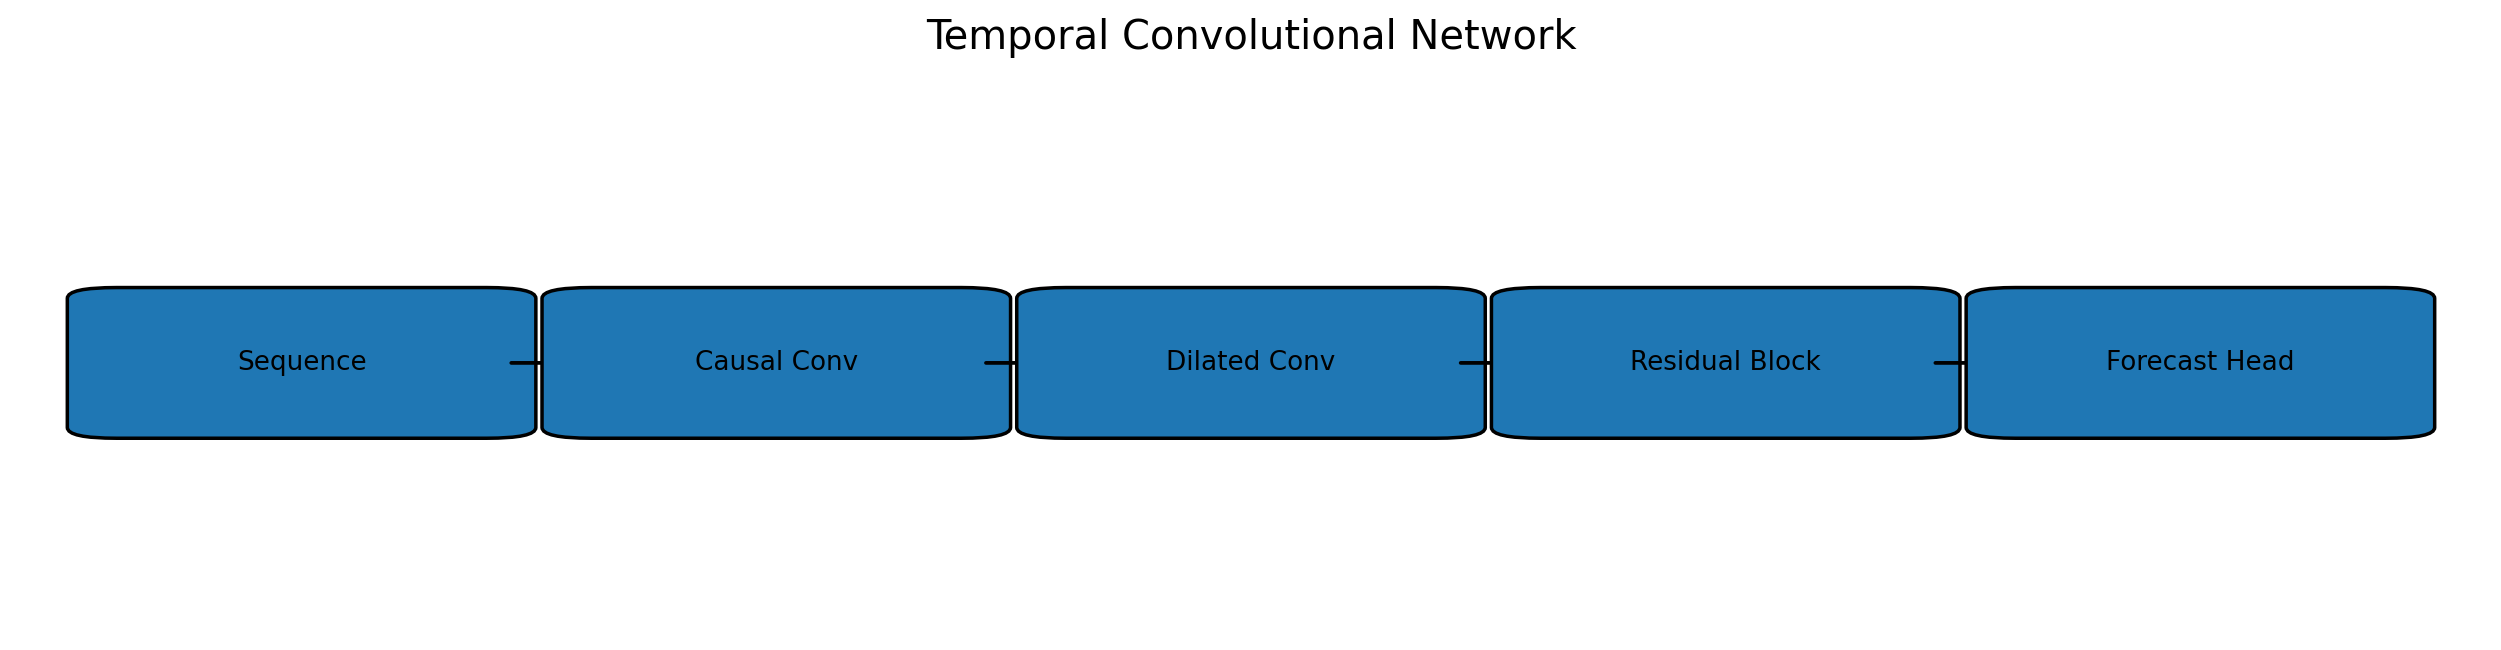

## 2. Learning Objectives

By the end of this notebook, you should be able to:

- explain why causal convolution is required for forecasting,
- distinguish ordinary padding from left-only causal padding,
- explain dilation,
- calculate a TCN receptive field,
- understand why dilation expands temporal context,
- build a causal convolution layer explicitly,
- verify causality experimentally,
- build residual TCN blocks,
- train a complete TCN forecaster,
- compare TCN with a seasonal-naive baseline,
- interpret the trade-off between receptive field and model depth.

## 3. Causality in Forecasting

At time \(t\), a valid model can use:

```text
t
t-1
t-2
...
```

but it must not use:

```text
t+1
t+2
...
```

A temporal convolution must therefore preserve this rule at every layer.

## 4. Ordinary Convolution Can Look Both Directions

Suppose a convolution kernel of size 3 is centered on time \(t\).

With symmetric padding, the computation may include:

```text
x(t-1), x(t), x(t+1)
```

For forecasting, \(x(t+1)\) is future information.

That would violate causality.

## 5. Causal Convolution

A causal kernel uses only the current and previous positions.

For a kernel of size 3:

```text
x(t-2), x(t-1), x(t)
```

The future is never included.

## 6. Imports and Reproducibility

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

np.random.seed(42)

torch.manual_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:")
print(device)

Device:
cpu


## 7. A Tiny Causal-Convolution Example

Start with a short sequence:

```text
[1, 2, 3, 4, 5]
```

For a kernel size of 3, the output at the third position may use:

```text
1, 2, 3
```

but not:

```text
4 or 5
```

In [2]:
toy_sequence = torch.tensor(
    [
        [
            [
                1.0,
                2.0,
                3.0,
                4.0,
                5.0
            ]
        ]
    ]
)

print("Toy sequence shape:")
print(
    toy_sequence.shape
)

print()

print("Toy sequence:")
print(
    toy_sequence
)

Toy sequence shape:
torch.Size([1, 1, 5])

Toy sequence:
tensor([[[1., 2., 3., 4., 5.]]])


## 8. Build a Causal Convolution Layer

Instead of symmetric padding, we add padding only on the **left**.

For kernel size \(k\) and dilation \(d\):

\[
left\ padding = (k-1)d
\]

In [3]:
class CausalConv1d(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation=1
    ):
        super().__init__()

        self.left_padding = (
            (kernel_size - 1)
            * dilation
        )

        self.convolution = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            dilation=dilation,
            padding=0
        )


    def forward(
        self,
        x
    ):

        x = F.pad(
            x,
            (
                self.left_padding,
                0
            )
        )

        output = self.convolution(
            x
        )

        return output

## 9. Inspect Shape Preservation

In [4]:
causal_layer = CausalConv1d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    dilation=1
)

with torch.no_grad():

    causal_output = causal_layer(
        toy_sequence
    )

print("Input length:")
print(
    toy_sequence.shape[
        2
    ]
)

print()

print("Output length:")
print(
    causal_output.shape[
        2
    ]
)

Input length:
5

Output length:
5


## 10. Verify Causality Experimentally

We change the **future end** of the sequence while keeping the early positions identical.

A causal layer should produce identical early outputs before the changed values become available.

In [5]:
sequence_a = torch.tensor(
    [
        [
            [
                1.0,
                2.0,
                3.0,
                4.0,
                5.0
            ]
        ]
    ]
)

sequence_b = torch.tensor(
    [
        [
            [
                1.0,
                2.0,
                3.0,
                100.0,
                200.0
            ]
        ]
    ]
)

with torch.no_grad():

    output_a = causal_layer(
        sequence_a
    )

    output_b = causal_layer(
        sequence_b
    )

print("Early output A:")
print(
    output_a[
        0,
        0,
        :3
    ]
)

print()

print("Early output B:")
print(
    output_b[
        0,
        0,
        :3
    ]
)

Early output A:
tensor([0.3951, 0.7391, 1.5244])

Early output B:
tensor([0.3951, 0.7391, 1.5244])


The first three outputs should match because the changed future values are not allowed to influence earlier positions.

## 11. What Is Dilation?

Dilation spaces kernel elements apart.

### Dilation 1

```text
x x x
```

### Dilation 2

```text
x . x . x
```

### Dilation 4

```text
x . . . x . . . x
```

This expands the temporal receptive field without requiring a very large kernel.

## 12. Receptive Field

The receptive field is the amount of history that can influence an output.

For one convolution:

\[
R = 1 + (k-1)d
\]

where:

- \(k\) = kernel size,
- \(d\) = dilation.

In [6]:
kernel_size = 3

dilations = [
    1,
    2,
    4,
    8
]

for dilation in dilations:

    receptive_field = (
        1
        + (kernel_size - 1)
        * dilation
    )

    print(
        "Dilation:",
        dilation,
        "| Single-layer receptive field:",
        receptive_field
    )

Dilation: 1 | Single-layer receptive field: 3
Dilation: 2 | Single-layer receptive field: 5
Dilation: 4 | Single-layer receptive field: 9
Dilation: 8 | Single-layer receptive field: 17


## 13. Stacked Dilated Convolutions

A common TCN uses exponentially increasing dilation:

```text
1 → 2 → 4 → 8 → 16
```

This lets deeper layers see increasingly long temporal history.

## 14. Why Residual Connections?

Deep dilated stacks can be difficult to optimize.

A residual block learns:

$$
y = F(x) + x
$$

This helps preserve information and gradient flow.

Residual connections also connect the TCN concept to ResNet and Transformer architectures studied earlier in the portfolio.

## 15. Load the Forecasting Dataset

In [8]:
"""data_path = "data/synthetic_hourly_demand.csv"

data = pd.read_csv(
    data_path
)

data["timestamp"] = pd.to_datetime(
    data["timestamp"]
)

data = data.set_index(
    "timestamp"
)

target = data[
    "demand"
].copy()

print("Number of observations:")
print(
    len(
        target
    )
)"""

'data_path = "data/synthetic_hourly_demand.csv"\n\ndata = pd.read_csv(\n    data_path\n)\n\ndata["timestamp"] = pd.to_datetime(\n    data["timestamp"]\n)\n\ndata = data.set_index(\n    "timestamp"\n)\n\ntarget = data[\n    "demand"\n].copy()\n\nprint("Number of observations:")\nprint(\n    len(\n        target\n    )\n)'

In [9]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

data = pd.read_csv(file_name)

data["timestamp"] = pd.to_datetime(data["timestamp"])

data = data.set_index("timestamp")

target = data["demand"].copy()

print("Number of observations:")
print(len(target))

Saving synthetic_hourly_demand.csv to synthetic_hourly_demand.csv
Number of observations:
4320


## 16. Use a Longer Lookback for the TCN

We use:

```text
lookback = 72 hours
```

so the network can exploit several daily cycles.

In [10]:
lookback = 72

number_of_rows = len(
    target
)

train_end = int(
    number_of_rows * 0.70
)

validation_end = int(
    number_of_rows * 0.85
)

train_series = target.iloc[
    :train_end
]

validation_series = target.iloc[
    train_end:validation_end
]

test_series = target.iloc[
    validation_end:
]

train_mean = train_series.mean()

train_std = train_series.std()

train_scaled = (
    train_series - train_mean
) / train_std

validation_scaled = (
    validation_series - train_mean
) / train_std

test_scaled = (
    test_series - train_mean
) / train_std

print("Lookback:")
print(
    lookback
)

Lookback:
72


## 17. Create Windows

In [11]:
def create_windows(
    values,
    lookback
):

    X = []

    y = []

    for start_index in range(
        0,
        len(values) - lookback
    ):

        end_index = (
            start_index + lookback
        )

        X.append(
            values[
                start_index:end_index
            ]
        )

        y.append(
            values[
                end_index
            ]
        )

    X = np.array(
        X,
        dtype=np.float32
    )

    y = np.array(
        y,
        dtype=np.float32
    )

    return X, y

In [12]:
X_train, y_train = create_windows(
    train_scaled.to_numpy(),
    lookback
)

X_validation, y_validation = create_windows(
    validation_scaled.to_numpy(),
    lookback
)

X_test, y_test = create_windows(
    test_scaled.to_numpy(),
    lookback
)

X_train = torch.tensor(
    X_train
).unsqueeze(
    1
)

X_validation = torch.tensor(
    X_validation
).unsqueeze(
    1
)

X_test = torch.tensor(
    X_test
).unsqueeze(
    1
)

y_train = torch.tensor(
    y_train
).unsqueeze(
    1
)

y_validation = torch.tensor(
    y_validation
).unsqueeze(
    1
)

print("TCN input shape:")
print(
    X_train.shape
)

TCN input shape:
torch.Size([2952, 1, 72])


TCN convention is:

```text
(batch, channels, time)
```

So the univariate sequence has one channel.

## 18. DataLoaders

In [13]:
batch_size = 64

train_loader = DataLoader(
    TensorDataset(
        X_train,
        y_train
    ),
    batch_size=batch_size,
    shuffle=True
)

validation_loader = DataLoader(
    TensorDataset(
        X_validation,
        y_validation
    ),
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:")
print(
    len(
        train_loader
    )
)

Training batches:
47


## 19. Build a Residual TCN Block

In [14]:
class TemporalResidualBlock(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation,
        dropout=0.1
    ):
        super().__init__()

        self.conv_1 = CausalConv1d(
            in_channels,
            out_channels,
            kernel_size,
            dilation
        )

        self.conv_2 = CausalConv1d(
            out_channels,
            out_channels,
            kernel_size,
            dilation
        )

        self.activation = nn.ReLU()

        self.dropout = nn.Dropout(
            dropout
        )

        if in_channels != out_channels:

            self.residual_projection = nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.residual_projection = nn.Identity()


    def forward(
        self,
        x
    ):

        residual = self.residual_projection(
            x
        )

        output = self.conv_1(
            x
        )

        output = self.activation(
            output
        )

        output = self.dropout(
            output
        )

        output = self.conv_2(
            output
        )

        output = self.activation(
            output
        )

        output = self.dropout(
            output
        )

        output = (
            output
            + residual
        )

        output = self.activation(
            output
        )

        return output

## 20. Build the Complete TCN

We use dilation:

```text
1, 2, 4, 8
```

with two causal convolutions per residual block.

In [15]:
class TCNForecaster(
    nn.Module
):

    def __init__(
        self
    ):
        super().__init__()

        self.block_1 = TemporalResidualBlock(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            dilation=1
        )

        self.block_2 = TemporalResidualBlock(
            in_channels=16,
            out_channels=16,
            kernel_size=3,
            dilation=2
        )

        self.block_3 = TemporalResidualBlock(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            dilation=4
        )

        self.block_4 = TemporalResidualBlock(
            in_channels=32,
            out_channels=32,
            kernel_size=3,
            dilation=8
        )

        self.output_layer = nn.Linear(
            32,
            1
        )


    def forward(
        self,
        x
    ):

        x = self.block_1(
            x
        )

        x = self.block_2(
            x
        )

        x = self.block_3(
            x
        )

        x = self.block_4(
            x
        )

        final_time_representation = x[
            :,
            :,
            -1
        ]

        prediction = self.output_layer(
            final_time_representation
        )

        return prediction

## 21. Calculate the Effective Receptive Field

With two convolutions per block, kernel size 3, and dilations 1, 2, 4, 8:

$$
R
=
1
+
2(k-1)
\sum d_i
$$

In [16]:
kernel_size = 3

dilations = [
    1,
    2,
    4,
    8
]

receptive_field = (
    1
    + 2
    * (kernel_size - 1)
    * sum(
        dilations
    )
)

print("Approximate TCN receptive field:")
print(
    receptive_field
)

print()

print("Lookback window:")
print(
    lookback
)

Approximate TCN receptive field:
61

Lookback window:
72


The receptive field should be large enough to cover most or all of the historical window we expect the model to use.

## 22. Inspect a Forward Pass

In [17]:
tcn_model = TCNForecaster()

tcn_model = tcn_model.to(
    device
)

example_batch = X_train[
    :8
].to(
    device
)

with torch.no_grad():

    example_prediction = tcn_model(
        example_batch
    )

print("Input shape:")
print(
    example_batch.shape
)

print()

print("Prediction shape:")
print(
    example_prediction.shape
)

Input shape:
torch.Size([8, 1, 72])

Prediction shape:
torch.Size([8, 1])


## 23. Parameter Count

In [18]:
total_parameters = 0

for parameter in tcn_model.parameters():

    total_parameters = (
        total_parameters
        + parameter.numel()
    )

print("TCN parameters:")
print(
    total_parameters
)

TCN parameters:
13905


## 24. Train the TCN

In [19]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    tcn_model.parameters(),
    lr=0.001
)

number_of_epochs = 20

training_losses = []

validation_losses = []

start_time = time.time()

for epoch in range(
    number_of_epochs
):

    tcn_model.train()

    training_loss_sum = 0.0

    training_batches = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(
            device
        )

        y_batch = y_batch.to(
            device
        )

        optimizer.zero_grad()

        predictions = tcn_model(
            X_batch
        )

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        training_loss_sum = (
            training_loss_sum
            + loss.item()
        )

        training_batches = (
            training_batches
            + 1
        )

    average_training_loss = (
        training_loss_sum
        / training_batches
    )

    tcn_model.eval()

    validation_loss_sum = 0.0

    validation_batches = 0

    with torch.no_grad():

        for X_batch, y_batch in validation_loader:

            X_batch = X_batch.to(
                device
            )

            y_batch = y_batch.to(
                device
            )

            predictions = tcn_model(
                X_batch
            )

            loss = criterion(
                predictions,
                y_batch
            )

            validation_loss_sum = (
                validation_loss_sum
                + loss.item()
            )

            validation_batches = (
                validation_batches
                + 1
            )

    average_validation_loss = (
        validation_loss_sum
        / validation_batches
    )

    training_losses.append(
        average_training_loss
    )

    validation_losses.append(
        average_validation_loss
    )

    print(
        "Epoch:",
        epoch + 1,
        "| Train:",
        round(
            average_training_loss,
            5
        ),
        "| Validation:",
        round(
            average_validation_loss,
            5
        )
    )

training_time = (
    time.time()
    - start_time
)

print()

print("Training time:")
print(
    training_time
)

Epoch: 1 | Train: 0.32755 | Validation: 0.19747
Epoch: 2 | Train: 0.12619 | Validation: 0.12249
Epoch: 3 | Train: 0.11666 | Validation: 0.11925
Epoch: 4 | Train: 0.11184 | Validation: 0.1168
Epoch: 5 | Train: 0.10792 | Validation: 0.11356
Epoch: 6 | Train: 0.10634 | Validation: 0.10771
Epoch: 7 | Train: 0.10189 | Validation: 0.11175
Epoch: 8 | Train: 0.09996 | Validation: 0.09734
Epoch: 9 | Train: 0.09857 | Validation: 0.12126
Epoch: 10 | Train: 0.10119 | Validation: 0.09977
Epoch: 11 | Train: 0.09989 | Validation: 0.10697
Epoch: 12 | Train: 0.09741 | Validation: 0.10045
Epoch: 13 | Train: 0.09856 | Validation: 0.09768
Epoch: 14 | Train: 0.09709 | Validation: 0.11224
Epoch: 15 | Train: 0.09968 | Validation: 0.11412
Epoch: 16 | Train: 0.0986 | Validation: 0.10376
Epoch: 17 | Train: 0.09646 | Validation: 0.1109
Epoch: 18 | Train: 0.09684 | Validation: 0.11794
Epoch: 19 | Train: 0.09341 | Validation: 0.12397
Epoch: 20 | Train: 0.0935 | Validation: 0.10885

Training time:
50.15216398239136

## 25. Learning Curves

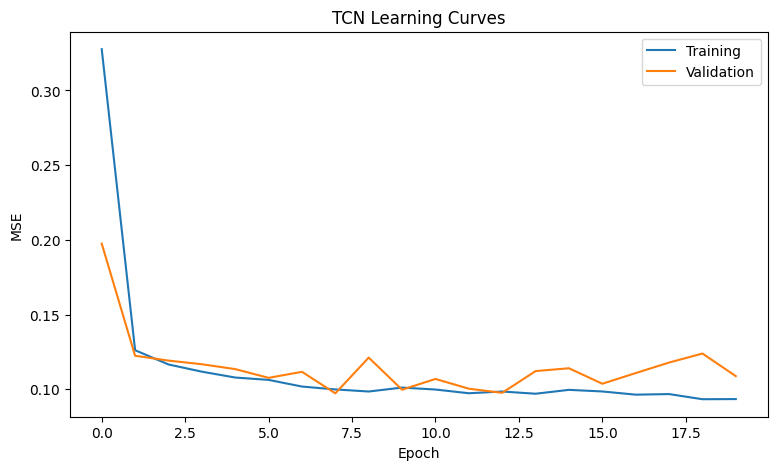

In [20]:
plt.figure(figsize=(9, 5))

plt.plot(
    training_losses,
    label="Training"
)

plt.plot(
    validation_losses,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("TCN Learning Curves")
plt.legend()

plt.show()

## 26. Generate Test Predictions

In [21]:
tcn_model.eval()

X_test_device = X_test.to(
    device
)

with torch.no_grad():

    test_predictions_scaled = tcn_model(
        X_test_device
    )

test_predictions_scaled = test_predictions_scaled.squeeze(
    1
)

test_predictions_scaled = test_predictions_scaled.cpu().numpy()

In [22]:
actual_test = (
    y_test
    * train_std
    + train_mean
)

tcn_predictions = (
    test_predictions_scaled
    * train_std
    + train_mean
)

seasonal_naive_scaled = X_test[
    :,
    0,
    -24
].numpy()

seasonal_naive_predictions = (
    seasonal_naive_scaled
    * train_std
    + train_mean
)

## 27. Compare TCN With Seasonal Naive

In [23]:
def calculate_mae(
    actual,
    predicted
):

    return np.mean(
        np.abs(
            actual - predicted
        )
    )


def calculate_rmse(
    actual,
    predicted
):

    return np.sqrt(
        np.mean(
            (
                actual - predicted
            ) ** 2
        )
    )

In [24]:
tcn_mae = calculate_mae(
    actual_test,
    tcn_predictions
)

tcn_rmse = calculate_rmse(
    actual_test,
    tcn_predictions
)

seasonal_mae = calculate_mae(
    actual_test,
    seasonal_naive_predictions
)

seasonal_rmse = calculate_rmse(
    actual_test,
    seasonal_naive_predictions
)

comparison = pd.DataFrame(
    [
        {
            "Model": "Seasonal Naive",
            "MAE": seasonal_mae,
            "RMSE": seasonal_rmse
        },
        {
            "Model": "TCN",
            "MAE": tcn_mae,
            "RMSE": tcn_rmse
        }
    ]
)

print(
    comparison
)

            Model       MAE      RMSE
0  Seasonal Naive  2.777083  3.435300
1             TCN  2.253821  2.765907


## 28. Plot the Forecast

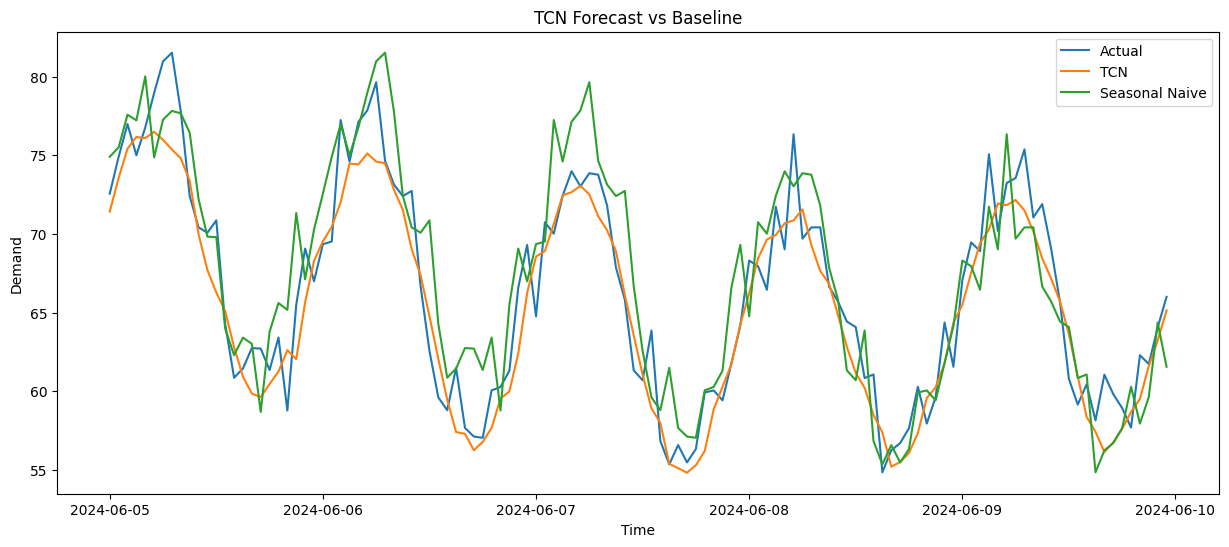

In [25]:
test_timestamps = test_series.index[
    lookback:
]

plot_length = 24 * 5

plt.figure(figsize=(15, 6))

plt.plot(
    test_timestamps[
        :plot_length
    ],
    actual_test[
        :plot_length
    ],
    label="Actual"
)

plt.plot(
    test_timestamps[
        :plot_length
    ],
    tcn_predictions[
        :plot_length
    ],
    label="TCN"
)

plt.plot(
    test_timestamps[
        :plot_length
    ],
    seasonal_naive_predictions[
        :plot_length
    ],
    label="Seasonal Naive"
)

plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("TCN Forecast vs Baseline")
plt.legend()

plt.show()

## 29. Why TCNs Can Be Attractive

Compared with recurrent networks, a TCN can offer:

- parallel convolutional computation,
- controllable receptive field,
- stable gradient flow through residual blocks,
- explicit temporal causality,
- efficient long-context modeling.

This does not mean TCN is always better. Performance depends on the data and forecast design.

## 30. Receptive-Field Design Experiment

A useful portfolio extension is to compare:

```text
dilations = [1, 2]
dilations = [1, 2, 4]
dilations = [1, 2, 4, 8]
dilations = [1, 2, 4, 8, 16]
```

Record:

- receptive field,
- parameter count,
- validation loss,
- test MAE,
- training time.

This demonstrates that TCN depth should be selected based on temporal context rather than added arbitrarily.

## 31. Limitations

This TCN experiment uses:

- univariate demand,
- one-step forecasting,
- fixed dilation schedule,
- fixed kernel size,
- no hyperparameter tuning,
- no probabilistic output.

The next notebook changes the forecasting problem itself by introducing **multiple variables and multiple future horizons**.

## 32. Key Takeaways

- Causal convolution prevents future information from entering earlier outputs.
- Dilation expands the receptive field efficiently.
- Residual connections improve deep temporal optimization.
- TCNs can model long histories without recurrent state.
- Receptive field should be matched to the forecasting context.
- Forecast performance must still be compared against simple temporal baselines.